In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/sample_data/datasets_11657_16098_train.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
x = df[['Pclass','Sex','Age','Fare']].copy()
y = df['Survived']

In [9]:
# Map 'Sex' column to numerical values
x['Sex'] = x['Sex'].map({'male': 0, 'female': 1})

# Display the head of the modified DataFrame to show the change
display(x.head())

,Pclass,Sex,Age,Fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,1,26.0,7.9250
3,1,1,35.0,53.1000
4,3,0,35.0,8.0500


In [11]:
x.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
Fare,0


In [13]:
# Fill null values in 'Age' column with the median
x['Age'].fillna(x['Age'].median(), inplace=True)

# Display the sum of null values after filling
x.isnull().sum()

/tmp/ipykernel_21645/1370853058.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Age'].fillna(x['Age'].median(), inplace=True)


,0
Pclass,0
Sex,0
Age,0
Fare,0


Survived
0    549
1    342
Name: count, dtype: int64


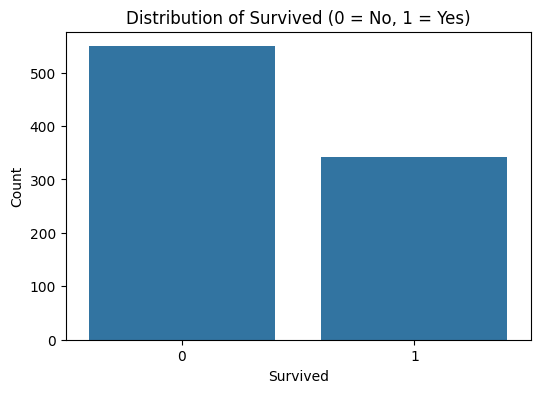

In [15]:
# Check the balance of the 'Survived' column
print(y.value_counts())

# Visualize the balance of the 'Survived' column
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Survived (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 4)
X_test shape: (179, 4)
y_train shape: (712,)
y_test shape: (179,)


### Decision Tree Classifier

Now, let's train a Decision Tree Classifier on our training data and visualize the resulting tree.

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


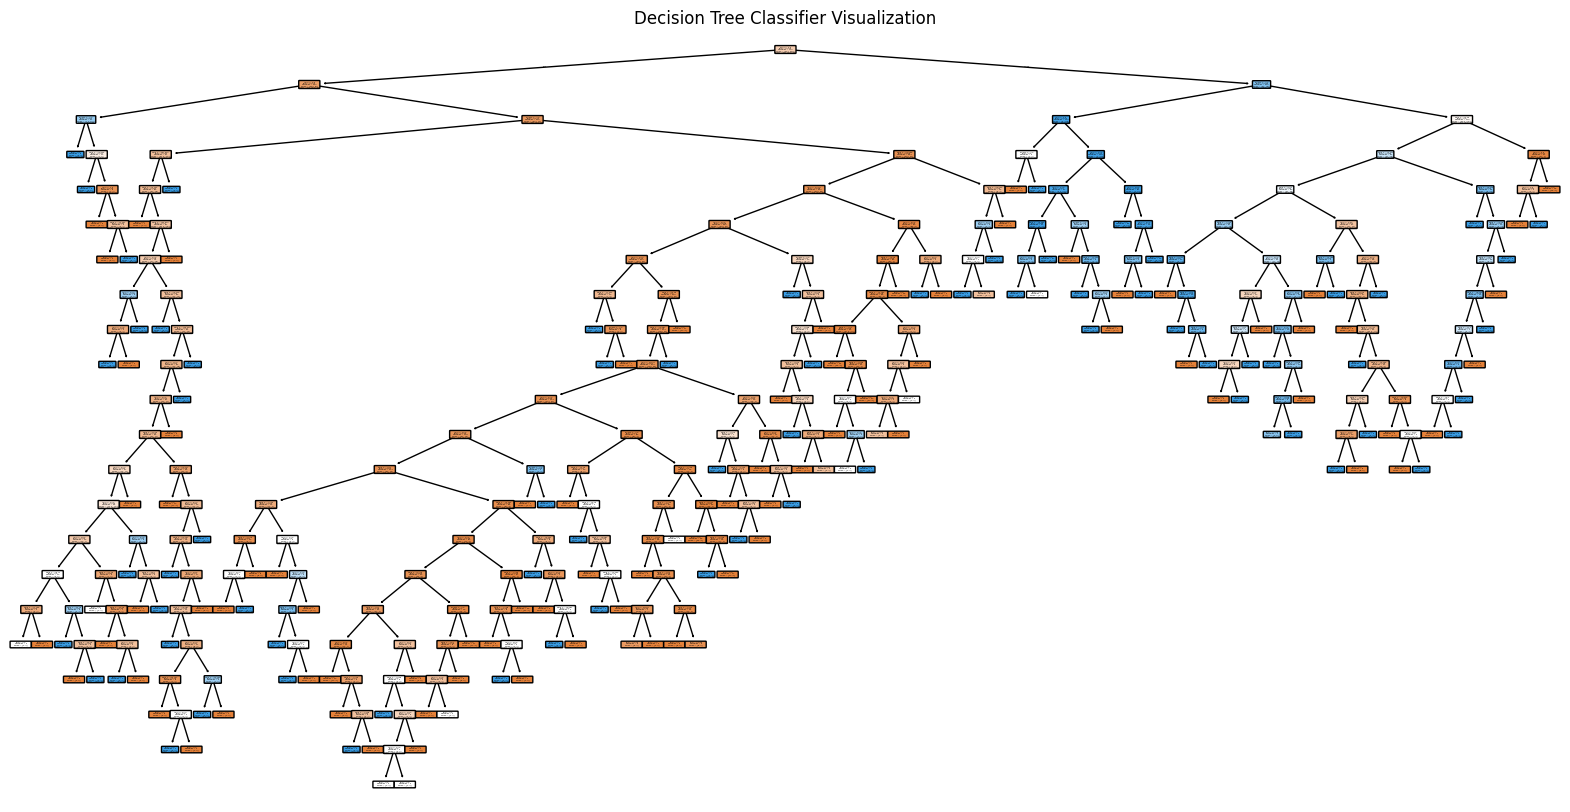

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X_train.columns, class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree Classifier Visualization')
plt.show()

In [19]:
from sklearn.metrics import classification_report

# Make predictions on the training data
y_train_pred = dtc.predict(X_train)
print("\nClassification Report for Training Data:")
print(classification_report(y_train, y_train_pred))

# Make predictions on the testing data
y_test_pred = dtc.predict(X_test)
print("\nClassification Report for Test Data:")
print(classification_report(y_test, y_test_pred))


Classification Report for Training Data:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       444
           1       0.99      0.95      0.97       268

    accuracy                           0.98       712
   macro avg       0.98      0.97      0.98       712
weighted avg       0.98      0.98      0.98       712


Classification Report for Test Data:
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       105
           1       0.66      0.72      0.69        74

    accuracy                           0.73       179
   macro avg       0.73      0.73      0.73       179
weighted avg       0.74      0.73      0.73       179



### Hyperparameter Tuning with GridSearchCV

Now, let's use GridSearchCV to find the optimal `max_depth` for our Decision Tree Classifier to potentially improve its performance and reduce overfitting.

In [20]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for max_depth
param_grid = {
    'max_depth': list(range(2, 21))
}

# Initialize a new Decision Tree Classifier (with random_state for reproducibility)
dt_classifier_grid = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_classifier_grid,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy', # Metric to optimize
    n_jobs=-1 # Use all available cores
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters found: {'max_depth': 3}
Best cross-validation accuracy: 0.8118


### Evaluate the Best Model

Now, let's get the best model from GridSearchCV and evaluate its performance on the test set.

In [21]:
# Get the best model
best_dt_model = grid_search.best_estimator_

# Make predictions on the test data using the best model
y_test_pred_best = best_dt_model.predict(X_test)

# Print the classification report for the best model on test data
print("\nClassification Report for Best Decision Tree Model on Test Data:")
print(classification_report(y_test, y_test_pred_best))


Classification Report for Best Decision Tree Model on Test Data:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### Applying SMOTE to Balance Training Data and Retraining the Model

Given the imbalance in the 'Survived' target variable and the potential for overfitting, we will use Synthetic Minority Over-sampling Technique (SMOTE) to balance the training data. After balancing, we will retrain our best Decision Tree model and evaluate its performance.

In [22]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of X_train before SMOTE:", X_train.shape)
print("Shape of y_train before SMOTE:", y_train.shape)
print("Shape of X_train after SMOTE:", X_train_resampled.shape)
print("Shape of y_train after SMOTE:", y_train_resampled.shape)

print("\nClass distribution before SMOTE:\n", y_train.value_counts())
print("\nClass distribution after SMOTE:\n", y_train_resampled.value_counts())

Shape of X_train before SMOTE: (712, 4)
Shape of y_train before SMOTE: (712,)
Shape of X_train after SMOTE: (888, 4)
Shape of y_train after SMOTE: (888,)

Class distribution before SMOTE:
 Survived
0    444
1    268
Name: count, dtype: int64

Class distribution after SMOTE:
 Survived
0    444
1    444
Name: count, dtype: int64


In [23]:
# Retrain the best Decision Tree model on the SMOTE-resampled data
best_dt_model_smote = best_dt_model.fit(X_train_resampled, y_train_resampled)

print("Decision Tree Classifier retrained with SMOTE-balanced data successfully!")

Decision Tree Classifier retrained with SMOTE-balanced data successfully!


In [24]:
# Make predictions on the test data using the SMOTE-retrained model
y_test_pred_smote = best_dt_model_smote.predict(X_test)

# Print the classification report for the SMOTE-retrained model on test data
print("\nClassification Report for Best Decision Tree Model (with SMOTE) on Test Data:")
print(classification_report(y_test, y_test_pred_smote))


Classification Report for Best Decision Tree Model (with SMOTE) on Test Data:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



### Bagging Classifier with Logistic Regression

Now, let's explore an ensemble method by applying a Bagging Classifier using Logistic Regression as the base estimator. We will train this model and evaluate its performance on both the training and test datasets.

In [25]:
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize the base estimator: Logistic Regression
# Set solver to 'liblinear' for small datasets or 'lbfgs' for larger ones.
# C is the inverse of regularization strength; smaller values specify stronger regularization.
logistic_reg = LogisticRegression(random_state=42, solver='liblinear', C=0.1)

# Initialize the Bagging Classifier
# n_estimators: number of base estimators (Logistic Regression models) in the ensemble
# max_samples: the number of samples drawn from X_train to train each base estimator
# max_features: the number of features drawn from X_train to train each base estimator
bagging_clf = BaggingClassifier(
    estimator=logistic_reg,
    n_estimators=10, # Number of logistic regression models to train
    max_samples=1.0, # Use all samples for each base estimator (can be a fraction)
    max_features=1.0, # Use all features for each base estimator (can be a fraction)
    bootstrap=True, # Sample with replacement
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train the Bagging Classifier
bagging_clf.fit(X_train, y_train)

print("Bagging Classifier with Logistic Regression trained successfully!")

Bagging Classifier with Logistic Regression trained successfully!


In [26]:
# Make predictions on the training data
y_train_pred_bagging = bagging_clf.predict(X_train)
print("\nClassification Report for Bagging Logistic Regression (Training Data):")
print(classification_report(y_train, y_train_pred_bagging))

# Make predictions on the testing data
y_test_pred_bagging = bagging_clf.predict(X_test)
print("\nClassification Report for Bagging Logistic Regression (Test Data):")
print(classification_report(y_test, y_test_pred_bagging))


Classification Report for Bagging Logistic Regression (Training Data):
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       444
           1       0.74      0.69      0.71       268

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.77       712
weighted avg       0.79      0.79      0.79       712


Classification Report for Bagging Logistic Regression (Test Data):
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



### Bagging Classifier with Decision Tree

Now, let's explore an ensemble method by applying a Bagging Classifier using a Decision Tree as the base estimator. We will train this model on the SMOTE-resampled data and evaluate its performance on both the training and test datasets.

In [27]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize the base estimator: Decision Tree Classifier
# Use the best max_depth found during GridSearchCV (which was 3)
dtc_base = DecisionTreeClassifier(max_depth=3, random_state=42)

# Initialize the Bagging Classifier
bagging_dt_clf = BaggingClassifier(
    estimator=dtc_base,
    n_estimators=10, # Number of decision trees to train
    max_samples=1.0, # Use all samples for each base estimator (can be a fraction)
    max_features=1.0, # Use all features for each base estimator (can be a fraction)
    bootstrap=True, # Sample with replacement
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train the Bagging Classifier on SMOTE-resampled data
bagging_dt_clf.fit(X_train_resampled, y_train_resampled)

print("Bagging Classifier with Decision Tree trained successfully!")

Bagging Classifier with Decision Tree trained successfully!


In [28]:
# Make predictions on the SMOTE-resampled training data
y_train_pred_bagging_dt = bagging_dt_clf.predict(X_train_resampled)
print("\nClassification Report for Bagging Decision Tree (Resampled Training Data):")
print(classification_report(y_train_resampled, y_train_pred_bagging_dt))

# Make predictions on the testing data
y_test_pred_bagging_dt = bagging_dt_clf.predict(X_test)
print("\nClassification Report for Bagging Decision Tree (Test Data):")
print(classification_report(y_test, y_test_pred_bagging_dt))


Classification Report for Bagging Decision Tree (Resampled Training Data):
              precision    recall  f1-score   support

           0       0.73      0.89      0.80       444
           1       0.85      0.67      0.75       444

    accuracy                           0.78       888
   macro avg       0.79      0.78      0.77       888
weighted avg       0.79      0.78      0.77       888


Classification Report for Bagging Decision Tree (Test Data):
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



### Random Forest Classifier

Let's train a Random Forest Classifier, which is another powerful ensemble method. We will use the SMOTE-resampled data for training and evaluate its performance on both the training and test datasets.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest.
# max_depth: The maximum depth of the tree (we'll start with 10 as a reasonable default, or can be tuned).
# random_state: For reproducibility.
# class_weight: To handle potential lingering imbalances if any, or just 'balanced' if not using SMOTE, but with SMOTE, we'll keep it default or 'balanced_subsample'.
rf_clf = RandomForestClassifier(n_estimators=9, max_depth=10, random_state=42, n_jobs=-1)

# Train the Random Forest Classifier on the SMOTE-resampled data
rf_clf.fit(X_train_resampled, y_train_resampled)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [34]:
# Make predictions on the SMOTE-resampled training data
y_train_pred_rf = rf_clf.predict(X_train_resampled)
print("\nClassification Report for Random Forest (Resampled Training Data):")
print(classification_report(y_train_resampled, y_train_pred_rf))

# Make predictions on the testing data
y_test_pred_rf = rf_clf.predict(X_test)
print("\nClassification Report for Random Forest (Test Data):")
print(classification_report(y_test, y_test_pred_rf))


Classification Report for Random Forest (Resampled Training Data):
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       444
           1       0.96      0.92      0.94       444

    accuracy                           0.94       888
   macro avg       0.94      0.94      0.94       888
weighted avg       0.94      0.94      0.94       888


Classification Report for Random Forest (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       105
           1       0.73      0.74      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



### Bagging Classifier with Random Forest

Let's combine the power of Bagging with Random Forest as the base estimator. We will train this ensemble model on the SMOTE-resampled data and evaluate its performance on both the training and test datasets.

In [35]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report

# Initialize the base estimator: Random Forest Classifier
# Using the parameters from our previous Random Forest, or a good default
rf_base = RandomForestClassifier(n_estimators=10, max_depth=10, random_state=42, n_jobs=-1)

# Initialize the Bagging Classifier
bagging_rf_clf = BaggingClassifier(
    estimator=rf_base,
    n_estimators=10, # Number of Random Forest models to train
    max_samples=1.0, # Use all samples for each base estimator (can be a fraction)
    max_features=1.0, # Use all features for each base estimator (can be a fraction)
    bootstrap=True, # Sample with replacement
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train the Bagging Classifier on SMOTE-resampled data
bagging_rf_clf.fit(X_train_resampled, y_train_resampled)

print("Bagging Classifier with Random Forest trained successfully!")

Bagging Classifier with Random Forest trained successfully!


In [36]:
# Make predictions on the SMOTE-resampled training data
y_train_pred_bagging_rf = bagging_rf_clf.predict(X_train_resampled)
print("\nClassification Report for Bagging Random Forest (Resampled Training Data):")
print(classification_report(y_train_resampled, y_train_pred_bagging_rf))

# Make predictions on the testing data
y_test_pred_bagging_rf = bagging_rf_clf.predict(X_test)
print("\nClassification Report for Bagging Random Forest (Test Data):")
print(classification_report(y_test, y_test_pred_bagging_rf))


Classification Report for Bagging Random Forest (Resampled Training Data):
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       444
           1       0.97      0.87      0.92       444

    accuracy                           0.92       888
   macro avg       0.93      0.92      0.92       888
weighted avg       0.93      0.92      0.92       888


Classification Report for Bagging Random Forest (Test Data):
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

